In [1]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from pathlib import Path
import scipy
from scipy.ndimage import gaussian_filter1d

In [3]:
# load gradient
grad = xr.open_dataset('NC_average_lat_lon_with_gradient.nc')

In [4]:
# crop to nobx
target_site = 'usa_NC_0032_0001'
start_idx = np.where(grad['site'].values == target_site)[0][0] + 200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(grad['site'].values == rodanthe_site)[0][0] - start_idx

grad_nobx = grad.isel(site=slice(start_idx, None))

In [18]:
# load nobx shoreline change data, match index to grad
lrr = pd.read_csv('coastsat_lrr_obx_1984_2025.csv').set_index('transect_id')

d_eta = xr.Dataset(
    {'d_eta': ('site', lrr['lrr_m_yr'].reindex(grad_nobx['site'].values).values)},
    coords={
        'site': grad_nobx['site'].values,
        'lat': ('site', grad_nobx['lat'].values),
        'lon': ('site', grad_nobx['lon'].values),
    },
)

In [19]:
# optimize d_eff_a by minimiziing Var(sa_x)
a = d_eta['d_eta']
b = grad_nobx['grad'] / 43

# use only sites where both are valid, so every term uses the same set of points
valid = a.notnull() & b.notnull()
a_v = a.where(valid)
b_v = b.where(valid)

cov_ab = float(((a_v - a_v.mean()) * (b_v - b_v.mean())).mean())
var_b = float(b_v.var())

c_opt = -cov_ab / var_b
d_eff_a = 1 / c_opt

sa_x = (a + c_opt * b).rename('sa_x')

r = cov_ab / np.sqrt(float(a_v.var()) * var_b)
print(f"D_eff* = {d_eff_a:.2f}")
print(f"Var(d_eta) = {float(a_v.var()):.4g},  Var(sa_x) = {float(sa_x.var()):.4g}")
print(f"Fraction of shoreline-change variance removed: {r**2:.1%}")

D_eff* = -552.75
Var(d_eta) = 1.812,  Var(sa_x) = 1.811
Fraction of shoreline-change variance removed: 0.0%


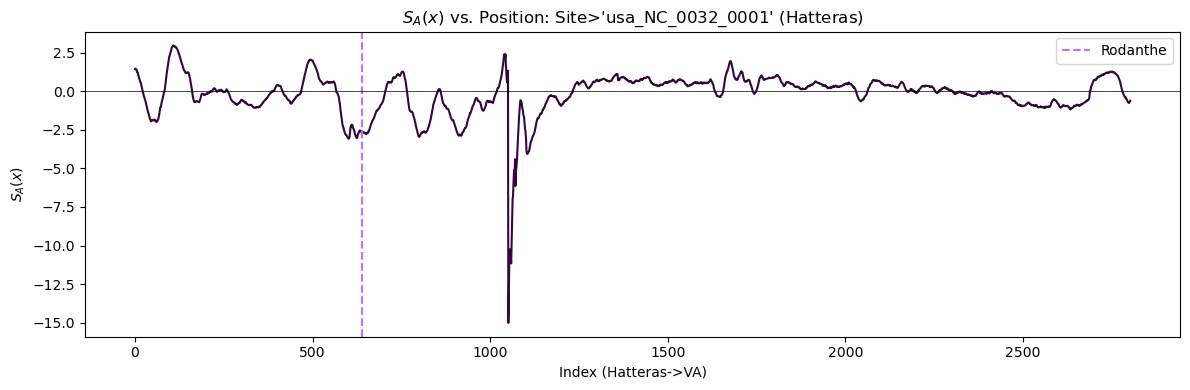

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sa_x.values, color='#35063E')
ax.axvline(x=rodanthe_idx, color='#C071FE', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"$S_A(x)$")
ax.set_title(f"$S_A(x)$ vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.legend()
plt.show()

In [9]:
# load curvature and diffusivity data, compute mean diff
curv = xr.open_dataset('NC_average_lat_lon_with_curvature.nc')
diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})
mean_diff = diff['mu'].mean(dim='time').compute()

/tmp/ipykernel_768635/1066022688.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})


In [20]:
# crop to nobx
target_site = 'usa_NC_0032_0001'
start_idx = np.where(curv['site'].values == target_site)[0][0]+200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(curv['site'].values == rodanthe_site)[0][0]-start_idx

curv_nobx = curv.isel(site=slice(start_idx, None))
mean_diff_nobx = mean_diff.isel(site=slice(start_idx, None))

In [21]:
a = d_eta['d_eta']
b = mean_diff_nobx * curv_nobx['curvature']

valid = a.notnull() & b.notnull()
a_v = a.where(valid)
b_v = b.where(valid)

cov_ab = float(((a_v - a_v.mean()) * (b_v - b_v.mean())).mean())
var_b = float(b_v.var())

c_opt = cov_ab / var_b
d_eff_b = 1 / c_opt

sb_x = (a - c_opt * b).rename('sb_x')

r = cov_ab / np.sqrt(float(a_v.var()) * var_b)
print(f"D_eff_b* = {d_eff_b:.4g}")
print(f"Var(d_eta) = {float(a_v.var()):.4g},  Var(sb_x) = {float(sb_x.var()):.4g}")
print(f"Fraction of shoreline-change variance removed: {r**2:.1%}")

D_eff_b* = -1.038e-06
Var(d_eta) = 1.842,  Var(sb_x) = 1.806
Fraction of shoreline-change variance removed: 1.9%


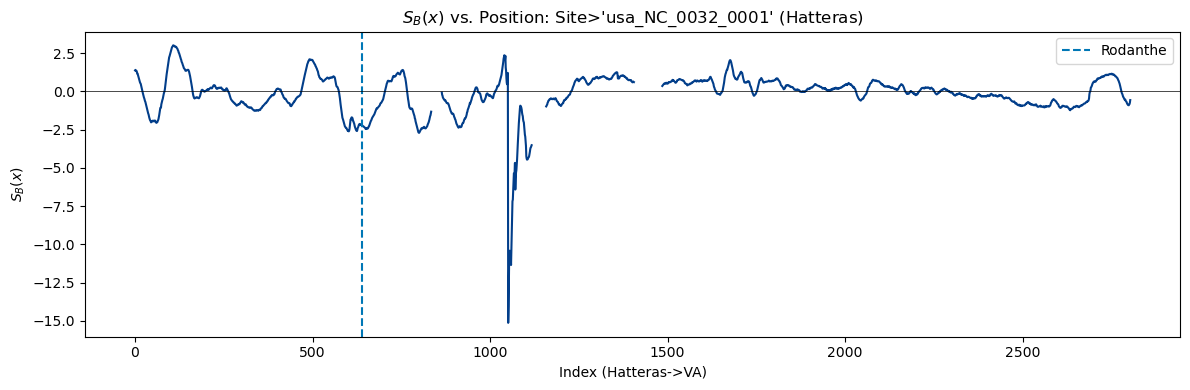

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sb_x.values, color='#023E8A')
ax.axvline(x=rodanthe_idx, color='#0077B6', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"$S_B(x)$")
ax.set_title(f"$S_B(x)$ vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.legend()
plt.show()

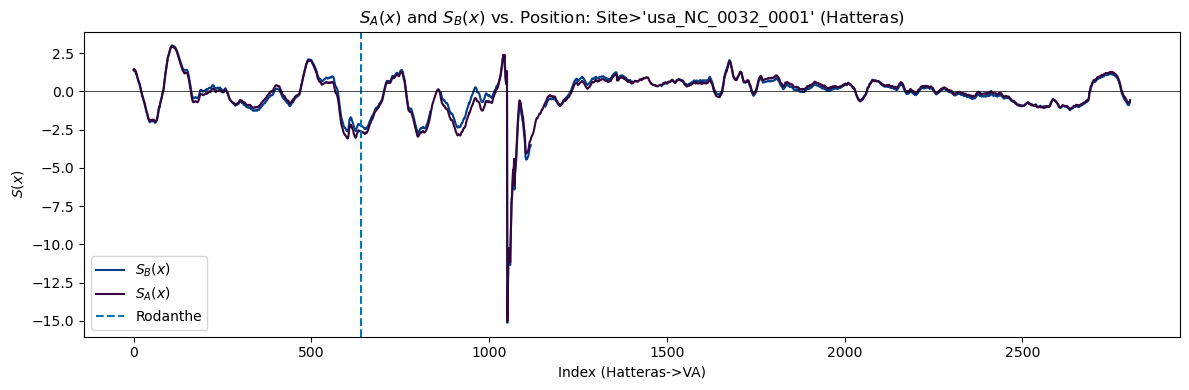

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sb_x.values, color='#023E8A', label=f'$S_B(x)$')
ax.plot(sa_x.values, color='#35063E', label=f'$S_A(x)$')
ax.axvline(x=rodanthe_idx, color='#0077B6', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"$S(x)$")
ax.set_title(f"$S_A(x)$ and $S_B(x)$ vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.legend()
plt.show()